In [1]:
import operator
from typing import Annotated, TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, START, StateGraph
from langgraph.types import Send
from pydantic import BaseModel, Field

load_dotenv(override=True)

MODEL_NAME = "gemini-3.6-flash"
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

## 추가 실습

면접 문제 생성

입력 : 지원자의 직무 / 경력 등 필요한 정보들  
orchestrator : 평가 역량(llm이 판단)  
worker : 하나의 역량에 대한 질문 생성.


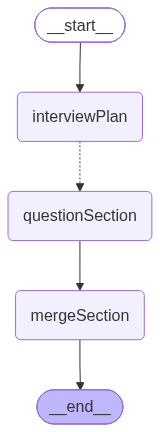

In [10]:
# section 부분
class Section(BaseModel):
    classification: str = Field(description="면접에 대한 분류") 
    evaluationCriteria: str = Field(description="면접에 대한 평가할 항목") 

# section 전체
class InterviewPlam(BaseModel):
    sections: list[Section] = Field(description="면접에 대한 분류, 항목을 모아놓은 리스트") 

# sectionState 부분
class SectionState(TypedDict):
    requset: str
    classification: str
    evaluationCriteria: str

# 전체 State
class InterviewState(TypedDict):
    request: str
    sections: list[Section]
    results: Annotated[list, operator.add]
    final_result: str


llm_with_interview_output = llm.with_structured_output(InterviewPlam)

def interviewPlan(state : InterviewState):
    request = state["request"]
    response = llm_with_interview_output.invoke(f"""
    다음 {request}를 보고 면접에 필요한 분류와 항목을 중복없이 5개 생성해줘
    """)
    return {"sections": response.sections}


def interviewWorkers(state : InterviewState):
    request = state["request"]

    return[
        Send(
            "questionSection",
            {
                "request": request,
                "classification": section.classification,
                "evaluationCriteria": section.evaluationCriteria,
            }
        )
        for section in state["sections"]
    ]

def questionSection(state : SectionState):
    classification = state["classification"]
    evaluationCriteria = state["evaluationCriteria"]

    response = llm.invoke(f"""
    {classification}와 {evaluationCriteria}이거를 보고 질문과 모범답안을 1개씩 만들어줘.
    """)
    return {
        "results":[{
            "content": response.text
        }]
    }


def mergeSection(state : InterviewState):
    results = state["results"]

    final_result = "\n\n".join(
        f"""
        {result["content"]} \n\n
        """
        for result in results
    )
    return {"final_result" : final_result}

builder = StateGraph(InterviewState)

builder.add_node("interviewPlan", interviewPlan)
builder.add_node("questionSection", questionSection)
builder.add_node("mergeSection", mergeSection)

builder.add_edge(START, "interviewPlan")
builder.add_conditional_edges(
    "interviewPlan",
    interviewWorkers,
    ["questionSection"]
)
builder.add_edge("questionSection", "mergeSection")
builder.add_edge("mergeSection", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [12]:
request = "신입 개발자, 파이썬과 자바를 언어로 사용, 현재 AI에이전트 공부 중"

result = graph.invoke({"request": request})

print(result["final_result"])


        제공해주신 평가 요소(**Python과 Java의 핵심 특징, 차이점 이해 및 상황별 적절한 활용 능력**)를 바탕으로, 실제 기술 면접이나 역량 평가에서 사용할 수 있는 **질문 1개**와 **모범답안 1개**를 작성해 드립니다.

---

### **[면접 질문]**

> **"Python과 Java는 현대 소프트웨어 개발에서 가장 널리 사용되는 두 언어이지만, 설계 철학과 기술적 특징에 큰 차이가 있습니다. 두 언어의 기술적 핵심 차이점(타이핑 시스템, 실행 방식 등)을 설명하고, 본인이 새로운 백엔드 프로젝트를 시작한다고 할 때 어떤 상황에서 Python을 선택하고, 어떤 상황에서 Java를 선택할지 기준을 제시해 주세요."**

---

### **[모범 답안]**

"Python과 Java는 **타이핑 시스템, 실행 모델, 그리고 생산성과 성능의 트레이드오프(Trade-off)** 관점에서 명확한 차이가 있습니다.

첫째, **타이핑 시스템**입니다. Python은 **동적 타이핑(Dynamic Typing)** 언어로 변수 선언 시 타입을 명시하지 않아 개발 속도가 빠르고 코드가 간결합니다. 반면 Java는 **정적 타이핑(Static Typing)** 언어로 컴파일 시점에 타입을 체크하여 코드의 안정성을 높이고 대규모 프로젝트에서 타입 관련 에러를 사전에 방지합니다.

둘째, **실행 방식과 성능**입니다. Python은 **인터프리터 언어**로서 한 줄씩 해석하며 실행되므로 개발 편의성은 높지만 실행 속도가 상대적으로 느립니다. 반면 Java는 **소스 코드를 바이트코드로 컴파일한 후 JVM(Java Virtual Machine) 위에서 JIT 컴파일러를 통해 실행**되므로, 메모리 관리와 실행 성능 면에서 우수하며 높은 대용량 트래픽 처리에 적합합니다.

이러한 특징을 바탕으로 프로젝트 상황에 맞게 언어를 선택할 수 있습니다.

*   **Python을 선택하는 상황:**
    1.  **AI/머신러닝 및 데이터 분석 기능이